<a href="https://colab.research.google.com/github/Miguel00andrad/analise_de_dados_ecommerce_olist/blob/main/Project_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🛍️ Projeto de Portfólio - Análise E-commerce

##Contexto
O conjunto de dados contém informações de 100 mil pedidos realizados entre 2016 e 2018 em diversos marketplaces no Brasil. Seus recursos permitem visualizar um pedido sob múltiplas perspectivas: desde o status do pedido, preço, pagamento e desempenho do frete até a localização do cliente, atributos do produto e, por fim, avaliações escritas pelos clientes. Também disponibilizamos um conjunto de dados de geolocalização que relaciona CEPs brasileiros a coordenadas de latitude e longitude.

Estes são dados comerciais reais, que foram anonimizados, e as referências às empresas e parceiros no texto da análise foram substituídas pelos nomes das grandes casas de Game of Thrones.

**Atenção:**

Um pedido pode conter vários itens.
Cada item pode ser enviado por um vendedor diferente.
Todo o texto que identificava lojas e parceiros foi substituído pelos nomes das grandes casas de Game of Thrones.


##Perguntas de Negócio
- Qual o faturamento total e o ticket médio por pedido?

- Existe sazonalidade? Quais meses ou dias da semana vendem mais?

- Quais categorias de produtos geram mais receita vs. volume de vendas?

- Logística: Qual a diferença média entre a data de entrega estimada e a data real?


##Informações do conjunto de dados (Tabelas)
1- orders: O "coração" do projeto. Tem o status do pedido e as datas (compra, aprovação, entrega).

2- order_items: Detalhes de cada item: preço, valor do frete e ID do vendedor.

3- products: Categoria do produto, peso e dimensões.

4- customers: Localização do cliente (cidade e estado).

5- order_reviews: Notas de 1 a 5 e comentários dos clientes.

6- order_payments: Forma de pagamento (cartão, boleto) e número de parcelas.

> Essa base de Dados está dividida em vários conjuntos de Dados, por isso o plano será: Tratar os dados das bases separadamente e depois unir o que eu precisar em um dataframe para a análise.




##Limpeza e Manipulação dos Dados

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

pd.options.display.float_format = '{:.2f}'.format
#Vamos criar o primeiro dataframe: vendas

# 1. Carregar os dados
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

#2. Converter colunas de data
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

#3. Unir pedidos com Itens (Para saber o que foi vendido em cada pedido)
df_vendas = pd.merge(orders, items, on='order_id', how='inner')

#4. Unir com Produtos (Para saber a categoria de cada item vendido)
df_vendas = pd.merge(df_vendas, products, on='product_id', how='inner')

#5. Unir com clientes
df_vendas = pd.merge(df_vendas, customers, on='customer_id', how='left')

#Como no SQL o merge funciona como um join entre as tabelas
df_vendas.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.00,4.00,500.00,19.00,8.00,13.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,178.00,1.00,400.00,19.00,13.00,19.00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,232.00,1.00,420.00,24.00,19.00,21.00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.00,3.00,450.00,30.00,10.00,20.00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,316.00,4.00,250.00,51.00,15.00,15.00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [ ]:
df_vendas.shape

(112650, 26)

In [ ]:
#Verificando informações do arquivo

df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   customer_id                    112650 non-null  object        
 2   order_status                   112650 non-null  object        
 3   order_purchase_timestamp       112650 non-null  datetime64[ns]
 4   order_approved_at              112635 non-null  object        
 5   order_delivered_carrier_date   111456 non-null  object        
 6   order_delivered_customer_date  110196 non-null  object        
 7   order_estimated_delivery_date  112650 non-null  object        
 8   order_item_id                  112650 non-null  int64         
 9   product_id                     112650 non-null  object        
 10  seller_id                      112650 non-null  object        
 11  

In [ ]:
#Verificando se há valores nulos na base de dados

df_vendas.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1194
order_delivered_customer_date,2454
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [ ]:
#Verificando se há valores duplicados em df_vendas

valores_duplicados = df_vendas.duplicated().sum()
print(f'Total de linhas duplicadas: {valores_duplicados}')

Total de linhas duplicadas: 0


In [ ]:
# Verificando estatísticas rápidas e outliers
print(df_vendas[['price', 'freight_value']].describe())

          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
max     6735.00         409.68


In [ ]:
#Total de valores únicos em cada variável

valores_unicos = []
for i in df_vendas.columns[0:15].to_list():
  print(i,':', len(df_vendas[i].astype(str).value_counts()))
  valores_unicos.append(len(df_vendas[i].astype(str).value_counts()))


order_id : 98666
customer_id : 98666
order_status : 7
order_purchase_timestamp : 98112
order_approved_at : 90175
order_delivered_carrier_date : 81018
order_delivered_customer_date : 95665
order_estimated_delivery_date : 450
order_item_id : 21
product_id : 32951
seller_id : 3095
shipping_limit_date : 93318
price : 5968
freight_value : 6999
product_category_name : 74


Feito uma avaliação geral dos dados, verificamos que há alguns valores nulos, por isso devemos tratá-los.

In [ ]:
# Filtra linhas com qualquer nulo
linhas_com_nulos = df_vendas[df_vendas.isna().any(axis=1)]
linhas_com_nulos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1,a1804276d9941ac0733cfd409f5206eb,...,NaN,NaN,600.00,35.00,35.00,15.00,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS
46,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00,1,c50ca07e9e4db9ea5011f06802c0aea0,...,1782.00,1.00,125.00,25.00,14.00,18.00,08fb46d35bb3ab4037202c23592d1259,13215,jundiai,SP
118,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00,1,1522589c64efd46731d3522568e5bc83,...,415.00,4.00,550.00,37.00,10.00,37.00,c7f8d7b1fffc946d7069574f74c39f4e,88140,santo amaro da imperatriz,SC
122,bfe42c22ecbf90bc9f35cf591270b6a7,803ac05904124294f8767894d6da532b,delivered,2018-01-27 22:04:34,2018-01-27 22:16:18,2018-02-03 03:56:00,2018-02-09 20:16:40,2018-02-26 00:00:00,1,71225f49be70df4297892f6a5fa62171,...,NaN,NaN,200.00,16.00,2.00,11.00,34c58672601f2c6d29db7efd1f6bf958,38650,bonfinopolis de minas,MG
148,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00,1,61d52f4882421048afd530db53d6f230,...,149.00,1.00,500.00,36.00,18.00,27.00,9f269af9c49244f6ba4a46985a3cfc2e,3436,sao paulo,SP


In [ ]:
#1. Pedidos sem data de entrega costumam ser cancelados ou pendentes. Vamos criar uma coluna para identificar isso e não enviesar o cálculo de frete.
df_vendas['is_delivered'] = df_vendas['order_delivered_customer_date'].notnull()

#2. Preecher categorias vazias com "Outros" ou "Nao Informado"
df_vendas['product_category_name'] = df_vendas['product_category_name'].fillna('Nao Informado')

#3. Vamos remover as linhas onde o preço é nulo (não vão nos ajudar na análise)
df_vendas.dropna(subset=['price'], inplace=True)

Na tabela orders, temos colunas como order_delivered_customer_date. Se você tentar calcular o tempo de entrega usando valores nulos (pedidos que ainda não chegaram ou foram cancelados), o Python vai retornar um erro ou um valor vazio.

**Solução**: Criar colunas chamada "Tempo de Entrega" apenas para pedidos com o status "Delivered"

In [ ]:
# Garantir que são objetos de data
cols_data = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in cols_data:
    df_vendas[col] = pd.to_datetime(df_vendas[col])

# Calcular dias de entrega (Real vs Estimado)
df_vendas['tempo_entrega_real'] = (df_vendas['order_delivered_customer_date'] - df_vendas['order_purchase_timestamp']).dt.days

## Análise Exploratória (EDA)

###Análise Univariada e Bivariada

--- Estatísticas de Preço ---
count   112650.00
mean       120.65
std        183.63
min          0.85
25%         39.90
50%         74.99
75%        134.90
max       6735.00
Name: price, dtype: float64


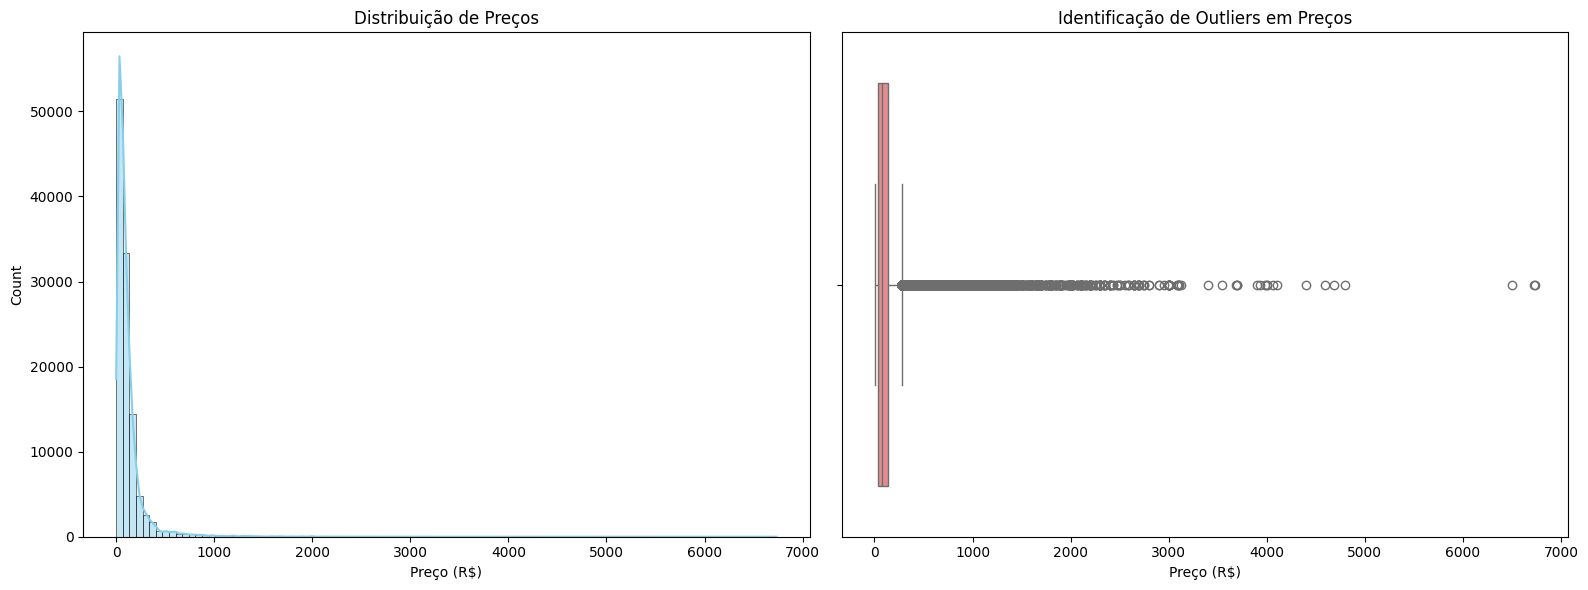

In [ ]:

# 2. Estatística Descritiva
print("--- Estatísticas de Preço ---")
print(items['price'].describe())

# 3. Criando as visualizações
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Histograma com KDE (Distribuição)
sns.histplot(items['price'], bins=100, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Preços')
axes[0].set_xlabel('Preço (R$)')

# Gráfico 2: Boxplot (Identificação de Outliers)
sns.boxplot(x=items['price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Identificação de Outliers em Preços')
axes[1].set_xlabel('Preço (R$)')

plt.tight_layout()
plt.show()

In [ ]:
# Criando categorias de preço para facilitar a análise no Power BI
bins = [0, 50, 100, 500, 1000, 10000]
labels = ['Econômico (até 50)', 'Baixo (50-100)', 'Médio (100-500)', 'Alto (500-1k)', 'Premium (+1k)']
items['faixa_preco'] = pd.cut(items['price'], bins=bins, labels=labels)

# Verificando a contagem por faixa
print(items['faixa_preco'].value_counts())

faixa_preco
Econômico (até 50)    39317
Médio (100-500)       37097
Baixo (50-100)        33020
Alto (500-1k)          2372
Premium (+1k)           844
Name: count, dtype: int64


In [ ]:
top_categorias = (
    df_vendas
    .groupby('product_category_name')
    .agg(
        price=('price', 'sum')
    )
    .reset_index()
    .sort_values(by='price', ascending=False)
    .head(10)
)



fig = px.bar(top_categorias,
             x='product_category_name',
             y='price',
             title='Top 10 Categorias por Faturamento',
             labels={'product_category_name': 'Categoria', 'price': 'Faturamento (R$)'},
             text_auto='.2s',
             color='price',
             color_continuous_scale='Blues')

fig.show()

In [ ]:
# Agrupando Faturamento e Volume por Estado (UF)
geo_analise = df_vendas.groupby('customer_state').agg({
    'price': 'sum',           # Faturamento Total
    'order_id': 'nunique'     # Quantidade de Pedidos Únicos
}).reset_index()

# Renomeando para facilitar
geo_analise.columns = ['UF', 'Faturamento', 'Qtd_Pedidos']

# Ordenando do maior para o menor faturamento
geo_analise = geo_analise.sort_values(by='Faturamento', ascending=False)

print(geo_analise.head())

    UF  Faturamento  Qtd_Pedidos
25  SP   5202955.05        41375
18  RJ   1824092.67        12762
10  MG   1585308.03        11544
22  RS    750304.02         5432
17  PR    683083.76         4998


A análise univariada geográfica revelou uma forte concentração de receita na região Sudeste (SP liderando isolado). Isso indica que a malha logística atual atende bem essa região, mas pode estar limitando a expansão nacional.

*Eles compram menos por falta de interesse no produto ou porque o frete é impeditivo?*

In [ ]:
# 1. Agrupando o valor MÉDIO do frete por estado
analise_frete = df_vendas.groupby('customer_state')['freight_value'].mean().reset_index()

# 2. Ordenando do frete mais caro para o mais barato
analise_frete = analise_frete.sort_values(by='freight_value', ascending=False)

# 3. Criando o gráfico de barras interativo
fig = px.bar(analise_frete,
             x='customer_state',
             y='freight_value',
             title='Média de Custo de Frete por Estado (UF)',
             labels={'customer_state': 'Estado (UF)', 'freight_value': 'Frete Médio (R$)'},
             text_auto='.2f', # Mostra o valor em cima da barra com 2 casas decimais
             color='freight_value',
             color_continuous_scale='Reds') # Escala de vermelho para destacar o "perigo" do frete alto

# Melhorando o layout para o portfólio
fig.update_layout(xaxis_tickangle=-45)
fig.show()

A análise bivariada evidenciou um forte gargalo logístico nas regiões Norte e Nordeste, onde o frete médio chega a ser 3x maior que no Sudeste. Como a maioria dos vendedores da Olist provavelmente está concentrada em SP/MG/RJ, o custo de transporte penaliza os clientes de regiões distantes. Isso explica a baixa penetração de mercado (baixo volume de pedidos) nesses estados.

/tmp/ipykernel_286/1763169042.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




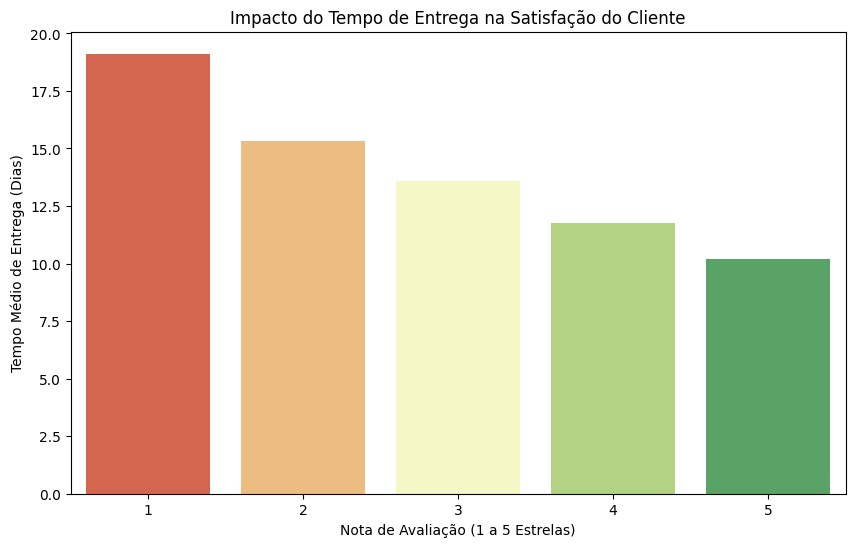

In [ ]:
reviews_simples = reviews[['order_id', 'review_score']]
df_vendas = pd.merge(df_vendas, reviews_simples, on='order_id', how='inner')

# 1. Agrupar a média de dias de entrega para cada nota (1 a 5)
analise_satisfacao = df_vendas.groupby('review_score')['tempo_entrega_real'].mean().reset_index()

# 2. Criar o gráfico de barras
plt.figure(figsize=(10, 6))

# Usamos uma paleta de cores (Vermelho para notas baixas, Verde para altas)
sns.barplot(data=analise_satisfacao, x='review_score', y='tempo_entrega_real', palette='RdYlGn')

plt.title('Impacto do Tempo de Entrega na Satisfação do Cliente')
plt.xlabel('Nota de Avaliação (1 a 5 Estrelas)')
plt.ylabel('Tempo Médio de Entrega (Dias)')
plt.show()

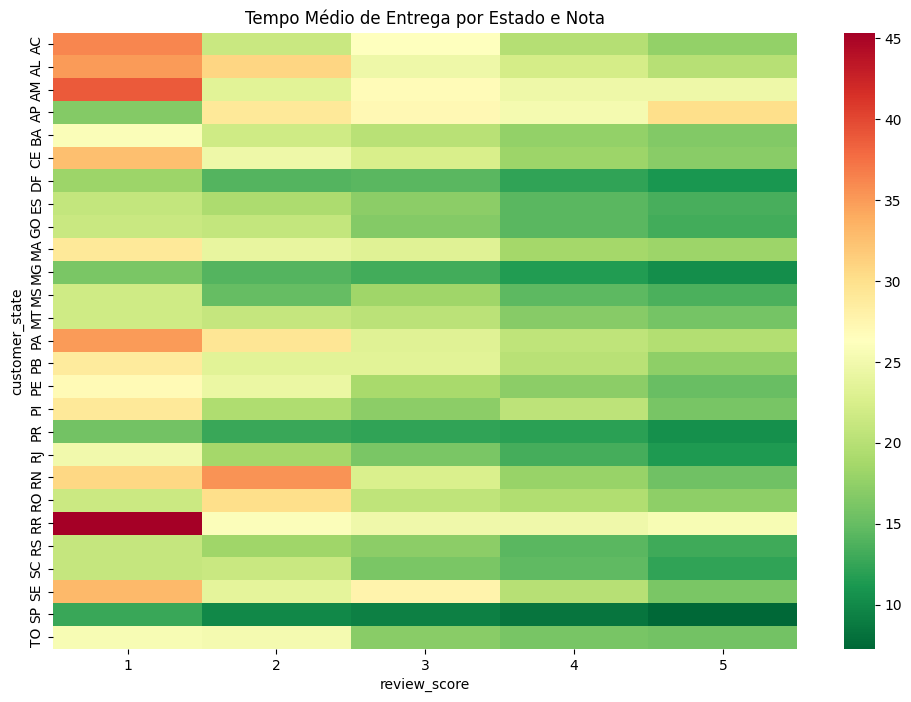

In [ ]:
analise_estado_satisfacao = (
    df_vendas
    .groupby(['customer_state', 'review_score'])
    .agg(
        tempo_medio_entrega=('tempo_entrega_real', 'mean'),
        qtd_avaliacoes=('review_score', 'count')
    )
    .reset_index()
)

pivot = analise_estado_satisfacao.pivot(
    index='customer_state',
    columns='review_score',
    values='tempo_medio_entrega'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='RdYlGn_r')
plt.title('Tempo Médio de Entrega por Estado e Nota')
plt.show()

A análise bivariada entre Logística e Satisfação refutou a hipótese de que o preço do produto dita a nota da avaliação. Os dados mostram que clientes que dão nota 1 esperam, em média, o dobro do tempo por suas encomendas em comparação aos clientes que dão nota 5. O plano de ação para aumentar o NPS (Net Promoter Score) da empresa deve ser estritamente focado em otimizar a rota de entrega e rever parceiros logísticos, especialmente nas regiões Norte e Nordeste, onde identificamos os fretes mais caros e demorados.

In [ ]:
# 1. Exportando as Tabelas Dimensão (Cadastros)
# Remova duplicatas se houver, para garantir que cada ID seja único
customers.drop_duplicates(subset='customer_id').to_csv('dim_clientes.csv', index=False)
products.drop_duplicates(subset='product_id').to_csv('dim_produtos.csv', index=False)

# 2. Exportando a Tabela Fato (O coração do negócio)
# Aqui juntamos apenas as ordens e os itens, mantendo os IDs para conectar depois
fato_vendas = pd.merge(orders, items, on='order_id', how='inner')

# Se você criou colunas novas (como tempo_entrega_real), garanta que elas estão aqui
fato_vendas.to_csv('fato_vendas.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np

# 1. Carregar as bases originais do Kaggle
print("Carregando os dados...")
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

# 2. Fazer os Merges (Unindo as tabelas)
# Começamos unindo os itens aos pedidos (cada linha será um item vendido)
print("Unindo as tabelas...")
df_flat = pd.merge(items, orders, on='order_id', how='inner')

# Unimos com os dados do cliente (para ter o estado e cidade)
df_flat = pd.merge(df_flat, customers, on='customer_id', how='inner')

# Unimos com os dados do produto (para ter a categoria)
df_flat = pd.merge(df_flat, products, on='product_id', how='inner')

# 3. Tratamento e Criação da Métrica de SLA
print("Calculando o SLA de entrega...")
# Convertendo para formato de data
df_flat['order_delivered_customer_date'] = pd.to_datetime(df_flat['order_delivered_customer_date'])
df_flat['order_estimated_delivery_date'] = pd.to_datetime(df_flat['order_estimated_delivery_date'])

# Lógica do SLA: 1 se chegou no prazo, 0 se atrasou. Nulos são ignorados.
df_flat['sla_entrega'] = np.where(
    df_flat['order_delivered_customer_date'].isnull(),
    np.nan, # Mantém vazio se o pedido foi cancelado ou não entregue
    np.where(df_flat['order_delivered_customer_date'] <= df_flat['order_estimated_delivery_date'], 1, 0)
)

# 4. Selecionar apenas as colunas úteis (Otimização)
# Isso evita que seu arquivo passe de 100MB e fique pesado no Looker Studio
colunas_finais = [
    'order_id',
    'price',
    'freight_value',
    'order_purchase_timestamp',
    'customer_state',
    'product_category_name',
    'sla_entrega'
]

df_looker = df_flat[colunas_finais]

# 5. Exportar o arquivo final consolidado
print("Exportando o arquivo final...")
df_looker.to_csv('dataset_looker_studio.csv', index=False)

print("✅ Sucesso! O arquivo 'dataset_looker_studio.csv' está pronto para ser carregado.")

Carregando os dados...
Unindo as tabelas...
Calculando o SLA de entrega...
Exportando o arquivo final...
✅ Sucesso! O arquivo 'dataset_looker_studio.csv' está pronto para ser carregado.


In [ ]:
import pandas as pd

# ---------------------------------------------------------
# 1. CARREGAR E LIMPAR AVALIAÇÕES (REVIEWS)
# ---------------------------------------------------------
print("Processando avaliações...")
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
# Mantemos apenas a nota e removemos duplicatas do mesmo pedido
df_reviews = df_reviews[['order_id', 'review_score']].drop_duplicates(subset=['order_id'])

# ---------------------------------------------------------
# 2. CARREGAR E LIMPAR PAGAMENTOS (PAYMENTS) - O SEGREDO!
# ---------------------------------------------------------
print("Processando pagamentos...")
df_payments = pd.read_csv('olist_order_payments_dataset.csv')

# Ordenamos do maior valor pago para o menor dentro de cada pedido
df_payments = df_payments.sort_values(by=['order_id', 'payment_value'], ascending=[True, False])

# Mantemos apenas a primeira linha de cada pedido (o método de pagamento principal)
# Isso impede que o faturamento seja duplicado no Looker Studio!
df_payments = df_payments.drop_duplicates(subset=['order_id'], keep='first')
df_payments = df_payments[['order_id', 'payment_type']]

# ---------------------------------------------------------
# 3. FAZER OS MERGES (CRUZAMENTOS) COM A SUA BASE PRINCIPAL
# ---------------------------------------------------------
print("Cruzando todas as tabelas...")
# Assumindo que o seu dataframe consolidado atual se chama 'df_looker'
df_looker = df_looker.merge(df_reviews, on='order_id', how='left')
df_looker = df_looker.merge(df_payments, on='order_id', how='left')

# Preencher possíveis valores nulos para o Looker não quebrar
df_looker['review_score'] = df_looker['review_score'].fillna(0)
df_looker['payment_type'] = df_looker['payment_type'].fillna('nao_informado')

# ---------------------------------------------------------
# 4. A GRANDE AGREGAÇÃO (REDUÇÃO DE LINHAS)
# ---------------------------------------------------------
df_looker['mes_ano'] = pd.to_datetime(df_looker['order_purchase_timestamp']).dt.to_period('M').astype(str)

print("Agregando os dados para o Looker Studio...")
# Agora colocamos review_score e payment_type como Dimensões (caixinhas)
df_agregado_final = df_looker.groupby([
    'mes_ano',
    'customer_state',
    'product_category_name',
    'review_score',
    'payment_type'
]).agg({
    'price': 'sum',              # Faturamento daquela combinação
    'freight_value': 'sum',      # Custo de frete
    'order_id': 'nunique',       # Quantidade de pedidos únicos
    'sla_entrega': 'mean'        # Média da taxa de entrega
}).reset_index()

# ---------------------------------------------------------
# 5. RENOMEAR E EXPORTAR O ARQUIVO LEVE
# ---------------------------------------------------------
df_agregado_final.rename(columns={
    'order_id': 'qtd_pedidos',
    'sla_entrega': 'taxa_sla_entrega'
}, inplace=True)

df_agregado_final.to_csv('dataset_looker_FINAL_Completo.csv', index=False)
print(f"✅ Arquivo final gerado com sucesso! Reduzido de mais de 100 mil para {len(df_agregado_final)} linhas agrupadas.")

Processando avaliações...
Processando pagamentos...
Cruzando todas as tabelas...
Agregando os dados para o Looker Studio...
✅ Arquivo final gerado com sucesso! Reduzido de mais de 100 mil para 34053 linhas agrupadas.


In [ ]:
df_agregado_final.head()

,mes_ano,customer_state,product_category_name,review_score,payment_type,price,freight_value,qtd_pedidos,taxa_sla_entrega
0,2016-09,RR,moveis_decoracao,1.00,credit_card,72.89,63.34,1,NaN
1,2016-09,RS,telefonia,1.00,credit_card,59.50,15.56,1,NaN
2,2016-09,SP,beleza_saude,1.00,nao_informado,134.97,8.49,1,0.00
3,2016-10,AL,automotivo,4.00,credit_card,49.99,26.61,1,1.00
4,2016-10,AL,informatica_acessorios,1.00,boleto,32.50,20.80,1,NaN
